This notebook implements computational experiments, and generates output data, in support of the `dbhdistfit_method-truncdata` article.

The purpose of the paper is to test our simplifed method for fitting truncated data to complete distributions (versus the recommended procedure using truncated forms of the distributions).

# Initialization

We starting by importing required modules, and setting notebook-global variables.

In [13]:
%matplotlib inline
import numpy as np
import scipy as sp
import pandas as pd
from pandas.compat import pickle_compat
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rc, rcParams
import matplotlib.font_manager
import math
from scipy import integrate
from scipy.special import gamma, beta
from scipy import stats # Import the scipy.stats module
import ipy_table as ipt
import pysal as ps
import geopandas as gpd
import shapely
from scipy.stats.distributions import t
from numpy import zeros, arange
from math import sqrt
from lmfit import Model, Parameter, MinimizerException
from lmfit.model import ModelResult
from functools import partial, wraps
from scipy.optimize import curve_fit as _curve_fit
from ipywidgets import FloatProgress
from IPython.display import display
import scipy.stats.distributions as distributions

try:
   import cPickle as pickle
except:
   import pickle


In [14]:
# monkey-patch the ModelResult class (add a method returning AICc)
def _aicc(self, dK):
    """Note that K=self.nvarys+1, to account for the implit error term."""
    K, n = self.nvarys+1, self.ndata
    K += dK
    return self.aic + 2*K*(K + 1.)/(n - K - 1.)
    
ModelResult.aicc = _aicc

In [15]:
show_progress = True
pd.set_option('display.max_columns', 10)
sns.set_style('white')
sns.set_context('paper', font_scale=1.)
sns.set_style('white')
rc('text',usetex=True)
rc('font',**{'family':'serif','serif':['Computer Modern']})
rcParams['text.latex.preamble']=r"\usepackage{bm}"


data_path = 'dat/'
size_classes = range(10, 60, 2) # 2 cm DBH classes in range [10, 60]
treatment_types = [1, 2, 3] # 1: clearcut, 2: selection cut, 3: commercial thin
cover_types = ['r', 'm', 'f'] # r: softwood, m: mixedwood, f: hardwood

essencegroupe1 = pd.read_csv(data_path+'misc/essencegroupe1.csv', index_col='groupe1')
groupe1groupe2groupe3 = pd.read_csv(data_path+'misc/groupe1groupe2groupe3.csv', index_col='groupe1')
groupe1 = sorted(groupe1groupe2groupe3.index.unique())
groupe2 = sorted(groupe1groupe2groupe3.groupe2.unique())
groupe3 = sorted(groupe1groupe2groupe3.groupe3.unique())
# map BFEC species group codes to MERIS species group codes (1:1 mapping)
species_groups = groupe1groupe2groupe3.reset_index().set_index('groupe3')['groupe1'].to_dict()
species_group_names = {'auf':'Other Hardwoods',
                       'boj':'Yellow Birch',
                       'bop':'Birch',
                       'chce':'Oak-Hickory',
                       'ers':'Maple',
                       'erx':'Other Maples',
                       'peu':'Poplar',
                       'pib':'White Pine',
                       'pir':'Red Pine',
                       'sepm':'SPFL', #'Fir-Spruce-Pine-Larch',
                       'topu':'Cedar'}
cover_type_names = {'r':'Softwood', 
                    'm':'Mixedwood',
                    'f':'Hardwood'}
cover_type_names_short = {'r':'S', 'm':'M', 'f':'H'}
dist_names_long = {'gb1':'GB1',
                   'gb2':'GB2',
                   'gg':'GG',
                   'ib1':'IB1',
                   'ug':'UG',
                   'b1':'B1',
                   'b2':'B2',
                   'sm':'SM',
                   'dagum':'Dagum',
                   'pareto':'Pareto',
                   'p':'P',
                   'ln':'LN',
                   'ga':'GA',
                   'w':'W',
                   'f':'F',
                   'l':'L',
                   'il':'IL',
                   'fisk':'Fisk',
                   'u':'U',
                   'halfn':r'$\tfrac{1}{2}\text{N}$',
                   'chisq':r'$\chi^2$',
                   'exp':'EXP',
                   'r':'R',
                   'halft':r'$\tfrac{1}{2}\text{t}$',
                   'll':'LL'}

In [16]:
from pandas.compat import pickle_compat
import pickle as _pickle

if not getattr(pickle_compat, '_legacy_blockmanager_patch', False):
    _orig_load_reduce = pickle_compat.load_reduce

    def _load_reduce(self):
        stack = self.stack
        args = stack.pop()
        func = stack[-1]
        try:
            stack[-1] = func(*args)
            return
        except TypeError:
            if args and isinstance(args[0], type) and args[0].__name__ in {'BlockManager', 'SingleBlockManager'}:
                cls = args[0]
                stack[-1] = cls.__new__(cls)
                return
        return _orig_load_reduce(self)

    pickle_compat.load_reduce = _load_reduce
    pickle_compat.Unpickler.dispatch[_pickle.REDUCE[0]] = _load_reduce
    pickle_compat._legacy_blockmanager_patch = True

with open(data_path+'misc/tiges_final_full.p', 'rb') as fh:
    df = pickle_compat.load(fh, encoding='latin1')
len(df)

23233

### Fit diameter distributions

We start by implementing GB1, GB2 and GG PDFs as follows. Note that we add a global scaling parameter $s$ to the implemented functions, to allow the fitting algorithm to compensate for the truncated sample domain (more on this later).

In [17]:
def gb1_pdf(x, a, b, p, q, s):
    y = s * ((abs(a) * pow(x, a*p-1.) * pow(1. - pow(x/b, a), q-1.)) / (pow(b, a*p) * beta(p, q)))
    return 0. if (np.any(np.isnan(y)) or np.any(np.isinf(y))) else y
    
def gb2_pdf(x, a, b, p, q, s, debug=True):
    if debug:
        if not np.all(np.array([isinstance(a, np.float64) or isinstance(a, float) for a in [a, b, p, q, s]])):
            print(a, type(a))
            print(b, type(b))
            print(p, type(p))
            print(q, type(q))
            print(s, type(s))
            for param in [a, b, p, q, s]:
                if isinstance(param, Parameter):
                    print(param)
    y = s * ((abs(a) * pow(x, a*p-1.)) / (pow(b, a*p) * beta(p, q) * pow(1. - pow(x/b, a), p+q)))
    return 0. if (np.any(np.isnan(y)) or np.any(np.isinf(y))) else y

def gg_pdf(x, a, beta, p, s):
    y = s * ((a * pow(x, a*p-1.) * np.exp(-pow(x/beta, a))) / (pow(beta, a*p) * gamma(p)))
    return 0. if (np.any(np.isnan(y)) or np.any(np.isinf(y))) else y

#def gg_cdf(x, a, beta, p, s):
#    X = np.array([i*1. for i in range(1, round(x))])
#    return sum(gg_pdf(X, a, beta, p, s))

def cdf(pdf, x, *args, **kwargs):
    X = np.array([i*1. for i in range(1, int(x)+1)])
    return sum(pdf(X, *args, **kwargs))

def ggt_pdf(x, a, beta, p, xmin=9., xmax=61.):
    y = gg_pdf(x, a, beta, p, 1.)
    y = 0. if (x < xmin or x >= xmax) else y
    y /= cdf(gg_pdf, xmax, a, beta, p, 1.) - cdf(gg_pdf, xmin, a, beta, p, 1.)
    return y




Now, we implement the 22 other distributions in the GB family by wrapping one of `gb1_pdf`, `gb2_pdf` or `gga_pdf` using the `lmfit.Model` class. A `Model` object wraps a distribution, a vector of parameters (with values and bounds), curve-fitting methods, and reporting methods. 

The `lmfit` package wraps the curve-fitting functions in `scipy.optimize`, but does a few cool things that are a PITA to implement otherwise:
* makes it easy to fix some of the parameters in the fit function
* makes it easy to define complex parameter bounds (including algebraic expressions referencing other parameters) 
* automatically calculates several goodness-of-fit metrics (chi2, AIC, BIC)
* makes it easy to implement our two-stage method (i.e. solve the model with _s_ free, fix _s_, solve again)

For the case of NLLS, AIC corresponds to

$$
\text{AIC} = 2k - n\ln\left(\frac{\chi^2}{n}\right)
$$

where $K=|\mathbf{P}|+1$ (i.e. the cardinality of the parameter vector $\mathbf{P}$, plus the $\mu$ parameter of the implicit i.i.d. Gaussian error distribution of input data vector $\mathbf{\hat{Y}}$), $n=|\mathbf{\hat{Y}}|$, and $\chi^2$ is the sum of squared residuals given by

$$
\chi^2 = \sum_{i \in I} \left[f(x_i; \hat{y}_i) - \hat{y}_i\right]^2
$$

AIC is theoretically valid asymtotically, however Burnham and Anderson (2002) recommend using AICc when $n/K < 40$ (with $K$ corresponding to one plus the largest parameter count among the distributions being tested on a given dataset). This is the case for our data, so we will use AICc to determine best-fit distributions. AICc is defined as

$$
\text{AICc} = \text{AIC} + \frac{2K(K + 1)}{n - K - 1}
$$

`lmfit` does not calculate AICc, so we monkey-patch the `lmfit.Model` class with an `aicc` method.

Next, we define a helper function that compiles data vectors $\mathbf{X}$ and $\mathbf{\hat{Y}}$ for use as input to the curve fitting function. 

Note that we normalize the data in $\mathbf{\hat{Y}}$ by default, such that $\sum_{i \in I} w\hat{y}_i = 1$ (i.e. area of bars in the histogram of the empirical distribution sums to 1). This normalization will make it easier to compare parameter estimation error output from the first stage of the fitting method across datasets. Note that this normalisation will only affect the value of the _s_ parameter (the second-stage parameter estimates should be unaffected by _a priori_ scaling of $\mathbf{\hat{Y}}$).    

In [18]:
def compile_bin_data(data, bins=None, xminmm=90, xmaxmm=610, xwmm=20, ef=25., alpha=0.05, pid_colname='id_pep', dbh_colname='dhpmm', normed=True, compile_stderr=False):
    #display(data)
    df = data.reset_index().set_index(pid_colname)
    if bins is None:
        bins = np.arange(xminmm, xmaxmm+xwmm, xwmm)

    bin_vals, bin_edges = np.histogram(df[dbh_colname], bins=bins, range=(xminmm, xmaxmm))
    bin_vals = bin_vals * ef # expand to stems/ha
    bin_stderrs = []
    if compile_stderr:
        for i, (xa, xb) in enumerate([(x, x+xwmm) for x in bins[:-1]]):
            #print 'processing bin', i
            Y = []
            for pid in df.index.unique():
                #print i, pid, len(df.index.unique())
                try:
                    _df = df.loc[[pid]].query('%s > %i & %s <= %i' % (dbh_colname, xa, dbh_colname, xb))
                except:
                    print(df.loc[pid]) 
                    raise
                Y.append(len(_df) * ef)
            sigma = sqrt((sum(y**2 for y in Y) - sum(Y)/len(Y))/(len(Y) - 1))
            t = distributions.t.ppf(1. - alpha/2., len(Y) - 1) 
            #print t*sigma
            bin_stderrs.append(t * sigma)
    else:
        bin_stderrs = [0. for i in bin_vals]
    bin_stderrs = np.array(bin_stderrs)
    bin_centers = (bin_edges[:-1] + (xwmm * 0.5)) * 0.1
    if normed: 
        scale = float(0.1 * xwmm * sum(bin_vals))
        bin_vals = bin_vals * pow(scale, -1)
        bin_stderrs = bin_stderrs * pow(scale, -1)
    return bin_centers, bin_vals, bin_edges * 0.1, bin_stderrs

In [19]:
@wraps(_curve_fit)
def curve_fit(*args, **kwargs):
    b = kwargs['bounds'] if 'bounds' in kwargs else None 
    if b and np.any(np.isfinite(b)) and 'max_nfev' not in kwargs:
        kwargs['max_nfev'] = kwargs.pop('maxfev', None)
    return _curve_fit(*args, **kwargs)

We start by defining a `dict` of lambda functions that specialize one of the three parent distributions, then we can use to compile a dict of `Model` objects in a loop.

Implement a function that selects the best model from a list of `(mr1, mr2)` tuples, based solely on AICc. Rejects any distribution with any best-fit parameter value exceeding `pvmax`.

In [20]:
def model_selector(model_list, pvmax=100.):
    _model_list = [m for m in model_list if np.all(np.array(list(m[1].best_values.values())) < pvmax)]
    min_aicc = min(mr2.aicc() for mr1, mr2 in _model_list)
    return min(_model_list, key=lambda mr: mr[1].aicc() - min_aicc)

In [21]:
def _model_selector(MR, daicc_thresh=10.):
    #for mr in MR:
    #    print mr.model._name, mr.aicc()
    min_aicc = min(mr.aicc() for mr in MR)
    min_rstderrn = np.inf
    for mr in MR:
        mrn = mr.model._name
        daicc = mr.aicc() - min_aicc
        #print mrn, daicc
        if daicc < daicc_thresh:
            rstderr = [mr.params[pn].stderr/mr.params[pn].value for pn in mr.params.keys() if mr.params[pn].vary]
            rstderrn = sum(rstderr) / len(rstderr)
            if rstderrn < min_rstderrn:
                min_rstderrn = rstderrn
                print(mr.model._name, rstderrn)
                best_mr = mr
    #daicc = {mr:(mr.aicc() - min_aicc) for mr in MR}
    #for mr in daicc:
    #    mr.daicc
    #print
    return mr

In [22]:
lim0 = 1e-10 #pow(np.nan_to_num(np.inf), -1)
D, B, M = {}, {}, {}

D['gb1'] = gb1_pdf
D['gb2'] = gb2_pdf
D['gg'] = gg_pdf
D['ib1'] = lambda x, b, p, q, s: gb1_pdf(x, -1., b, p, q, s)
D['ug'] = lambda x, b, d, q, s: gb1_pdf(x, lim0, b, d/lim0, q, s)
D['b1'] = lambda x, b, p, q, s: gb1_pdf(x, 1., b, p, q, s)
D['b2'] = lambda x, b, p, q, s: gb2_pdf(x, 1., b, p, q, s)
D['sm'] = lambda x, a, b, q, s: gb2_pdf(x, a, b, 1., q, s)
D['dagum'] = lambda x, a, b, p, s: gb2_pdf(x, a, b, p, 1., s)
D['pareto'] = lambda x, b, p, s: gb1_pdf(x, -1., b, p, 1., s)
D['p'] = lambda x, b, p, s: gb1_pdf(x, 1., b, p, 1., s)
D['ln'] = lambda x, mu, ss, s: gg_pdf(x, lim0, pow(ss*lim0**2, 1./lim0), (lim0*mu+1.) / (ss*lim0**2), s)
D['ga'] = lambda x, beta, p, s: gg_pdf(x, 1., beta, p, s)
D['w'] = lambda x, a, beta, s: gg_pdf(x, a, beta, 1., s)
D['f'] = lambda x, u, v, s: gb2_pdf(x, 1., v/u, u/2., v/2., s)
D['l'] = lambda x, b, q, s: gb2_pdf(x, 1., b, 1., q, s)
D['il'] = lambda x, b, p, s: gb2_pdf(x, 1., b, p, 1., s)
D['fisk'] = lambda x, a, b, s: gb2_pdf(x, a, b, 1., 1., s)
D['u'] = lambda x, b, s: gb1_pdf(x, 1., b, 1., 1., s)
D['halfn'] = lambda x, ss, s: gg_pdf(x, 2., ss, 0.5, s)
D['chisq'] = lambda x, p, s: gg_pdf(x, 1., 2., p, s)
D['exp'] = lambda x, beta, s: gg_pdf(x, 1., beta, 1., s)
D['r'] = lambda x, beta, s: gg_pdf(x, 2., beta, 1., s)
D['halft'] = lambda x, df, s: gb2_pdf(x, 2., df**0.5, 0.5, df/2., s)
D['ll'] = lambda x, b, s: gb2_pdf(x, 1., b, 1., 1., s)

xmin, xmax = 10., 60.
#B['gb1'] = ((-np.inf, np.inf), (0., np.inf), (0., np.inf), (0., np.inf), (0., np.inf))
B['gb1'] = ((-10., 10.), (0., np.inf), (0., np.inf), (0., np.inf), (0., np.inf))
B['gb2'] = ((0., np.inf), (0., np.inf), (0., np.inf), (0., np.inf), (0., np.inf))
B['gg'] = ((0., np.inf), (0., np.inf), (0., np.inf), (0., np.inf))
B['ib1'] = ((0., xmax), (0., np.inf), (0., np.inf), (0., np.inf))
B['ug'] = ((0., np.inf), (0., np.inf), (0., np.inf), (0., np.inf))
B['b1'] = ((xmax, np.inf), (0., np.inf), (0., np.inf), (0., np.inf))
B['b2'] = ((0., np.inf), (0., np.inf), (0., np.inf), (0., np.inf))
B['sm'] = ((0., np.inf), (0., np.inf), (0., np.inf), (0., np.inf))
B['dagum'] = ((0., np.inf), (0., np.inf), (0., np.inf), (0., np.inf))
B['pareto'] = ((0., np.inf), (0., np.inf), (0., np.inf), (0., np.inf))
B['p'] = ((0., np.inf), (0., np.inf), (0., np.inf))
B['ln'] = ((0., np.inf), (0., np.inf), (0., np.inf))
B['ga'] = ((0., np.inf), (0., np.inf), (0., np.inf))
B['w'] = ((0., np.inf), (0., np.inf), (0., np.inf))
B['f'] = ((0., np.inf), (0., np.inf), (0., np.inf))
B['l'] = ((0., np.inf), (0., np.inf), (0., np.inf))
B['il'] = ((0., np.inf), (0., np.inf), (0., np.inf))
B['fisk'] = ((0., np.inf), (0., np.inf), (0., np.inf))
B['u'] = ((0., np.inf), (0., np.inf))
B['halfn'] = ((0., np.inf), (0., np.inf))
B['chisq'] = ((0., np.inf), (0., np.inf))
B['exp'] = ((0., np.inf), (0., np.inf))
B['r'] = ((0., np.inf), (0., np.inf))
B['halft'] = ((0., np.inf), (0., np.inf))
B['ll'] = ((0., np.inf), (0., np.inf))

Next, we fit each of the 25 distributions in `D` to each of the 30 subdatasets, using our two-stage methodology (i.e. fix the `s` parameter in the second stage). 

We implement a series of filters to reject the fit (returning `None, None` as a result) if something seems to have gone awry. Fit is rejected if any of the following conditions are met
* The NLLS algorithm raises an exception (i.e. does not converge).
* Any of the fit parameters has a values of either `NaN` or `inf`, after either stage.
* Any of the parameter error estimates is equal to 0, after either stage.
* The absolute value of the ratio of parameter error and parameter value exceeds 1 (i.e. $|\hat{p}_j/\sigma_{\hat{p}_j}| > 1, \forall j \in J$), after either stage.

These criteria are rather strict, so we can say that our methodology is quite conservative.

In [23]:
def fitf(f, X, Y, stderrs, method):
    assert method in ['1sc', '1st', '2sc']
    m = Model(f)
    bounds = (list(zip(*[(0., np.inf) for _ in m.param_names])))
    #bounds = (list(zip(*[(0., 100.) for _ in m.param_names])))
    #print(m.param_names, bounds)
    m._name = dn
    popt = None
    try:
        popt, _ = curve_fit(f, X, Y, maxfev=maxfev, bounds=bounds)
    except:
        print('curve_fit failed (proceeding without param hints)')
    lb, ub = bounds
    if popt is not None:
        #print(m.param_names, popt, lb, ub)
        for i, pn in enumerate(m.param_names):
            m.set_param_hint(pn, value=popt[i], min=lb[i], max=ub[i])
    weights = 1. - np.array([stderr/y for stderr, y in list(zip(stderrs, Y))]) if compile_stderr else np.array([1. for y in Y])
    mr1 = m.fit(Y, x=X, weights=weights)
    if method in ['1sc', '1st']:
        return mr1
    elif method in ['2sc']:
        mr1.model.set_param_hint('s', vary=False)
        mr2 = mr1.model.fit(Y, x=X, weights=weights)
        return mr2

In [24]:
df = df.reset_index().set_index(['groupe3', 'type_couv'])
maxfev = 100000
compile_stderr = True
#sg, ct = 'peu', 'm'
sg, ct = 'bop', 'f'
_df = df.loc[sg].loc[ct]
X, Y, bins, stderrs = compile_bin_data(_df, compile_stderr=compile_stderr)
X, Y, stderrs = zip(*[(x, y, stderr) for x, y, stderr in zip(X, Y, stderrs) if y > 0])

In [25]:
vggt_pdf = np.vectorize(ggt_pdf)
vgg_pdf = np.vectorize(gg_pdf)

wt_pdf = lambda x, a, beta: vggt_pdf(x, a, beta, 1.)
w_pdf = lambda x, a, beta, s: vgg_pdf(x, a, beta, 1., s)
wc_pdf = lambda x, a, beta: vgg_pdf(x, a, beta, 1., 1.)

gt_pdf = lambda x, beta, p: vggt_pdf(x, 1., beta, p)
g_pdf = lambda x, beta, p, s: vgg_pdf(x, 1., beta, p, s)
gc_pdf = lambda x, beta, p: vgg_pdf(x, 1., beta, p, 1.)

#gt_pdf = lambda x, a, beta, p: vggt_pdf(x, a, beta, p)
#g_pdf = lambda x, a, beta, p, s: vgg_pdf(x, a, beta, p, s)
#gc_pdf = lambda x, a, beta, p: vgg_pdf(x, a, beta, p, 1.)

In [26]:
distns = [('w', (wc_pdf, wt_pdf, w_pdf)), ('ga', (gc_pdf, gt_pdf, g_pdf))]
mplots = [('sepm', 'r'), ('peu', 'm'), ('bop', 'f')]
mplots = [('sepm', 'r'), ('bop', 'm'), ('ers', 'f')]
bm = {}
for j, v in enumerate(mplots):
    sg, ct = v
    bm[v] = {}
    _df = df.loc[sg].loc[ct]
    X, Y, bins, stderrs = compile_bin_data(_df, compile_stderr=compile_stderr)
    X, Y, stderrs = zip(*[(x, y, stderr) for x, y, stderr in zip(X, Y, stderrs) if y > 0])
    for i, d in enumerate(distns):
        dn, f = d
        print(sg, ct, dn)
        bm[v][dn] = {'1sc':fitf(f[0], X, Y, stderrs, method='1sc'),
                     '1st':fitf(f[1], X, Y, stderrs, method='1st'),
                     '2sc':fitf(f[2], X, Y, stderrs, method='2sc')}

sepm r w
sepm r ga
bop m w
bop m ga
ers f w
ers f ga


In [ ]:
fig, ax = plt.subplots(3, 2, figsize=(6, 7), sharey=True, sharex=True)
plot_stderr = True
for i, v in enumerate(mplots):
    sg, ct = v
    for j, d in enumerate(distns):
        dn, f = d
        _df = df.loc[sg].loc[ct]
        X, Y, bins, stderrs = compile_bin_data(_df, compile_stderr=compile_stderr)
        X, Y, stderrs = zip(*[(x, y, stderr) for x, y, stderr in zip(X, Y, stderrs) if y > 0])
        ax[i][j].set_xlabel('')
        ax[i][j].plot(X, Y, marker='o', markersize=4, linestyle='', color='k', alpha=0.5, label=r'$\hat{y}_i$')
        if plot_stderr:
            ax[i][j].errorbar(X, Y, yerr=stderrs, fmt='none', ecolor='k', alpha=0.2, label='$\pm t \sigma_{\hat{y}_i}$')
        ax[i][j].plot(X, bm[v][dn]['1sc'].best_fit, color='k', alpha=0.5, linestyle='-', label=r'%s$(x; \bm{\hat{P}})$' % dist_names_long[dn] + '(1sc)')
        ax[i][j].plot(X, bm[v][dn]['1st'].best_fit, color='k', alpha=0.5, linestyle='--', label=r'%s$(x; \bm{\hat{P}})$' % dist_names_long[dn] + '(1st)')
        ax[i][j].plot(X, bm[v][dn]['2sc'].best_fit, color='k', alpha=0.5, linestyle=':', label=r'%s$(x; \bm{\hat{P}})$' % dist_names_long[dn] + '(2sc)')
        #ax.set_ylim(ylim)
        ax[i][j].legend(prop={'size':6})
        #ax[1][j].set_ylabel('Meta-plot %s, %s' % (sg, ct))
        ax[i][0].set_ylabel('Relative Frequency')
        sgn = species_group_names[sg]
        ctn = cover_type_names_short[ct]
        dns = dist_names_long[dn]
        ax[i][j].set_xlabel('Meta-plot: %s-%s, Distribution: %s' % (sgn, ctn, dns))
plt.tight_layout()
plt.savefig(data_path + 'dbhdistfit_method-truncdata1.pdf', format='pdf')
        
        


<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_4178502/968135439.py:13: SyntaxWarning: invalid escape sequence '\p'
  ax[i][j].errorbar(X, Y, yerr=stderrs, fmt='none', ecolor='k', alpha=0.2, label='$\pm t \sigma_{\hat{y}_i}$')


Output best-fit results in (LaTeX-friendly) tabular form. Publish results from both stages.

In [ ]:
#_aicc = []
dK = {'1sc':0, '1st':2, '2sc':1}
for i, v in enumerate(mplots):
    sg, ct = v
    for j, d in enumerate(distns):
        dn, f = d
        _aicc = {fm:mr.aicc(dK[fm]) for fm, mr in bm[v][dn].items()}
        daicc = {fm:(_aicc[fm] - min(_aicc.values())) for fm in _aicc}
        for k, (fm, mr) in enumerate(bm[v][dn].items()):
            params = [(pn, mr.params[pn].value, mr.params[pn].stderr) for pn in mr.params.keys() if mr.params[pn].vary] 
            params_str = [('%s = %.2f$\pm$%.2f' % (pn, v, e)).replace('beta', '$\\beta$') for pn, v, e in params]
            for l, p in enumerate(params_str):     
                sgn = species_group_names[sg] if not j and not k and not l else ''
                ctn = cover_type_names_short[ct] if not j and not k and not l else ''
                dns = dist_names_long[mr.model._name] if not k and not l else ''
                fms = fm if not l else ''
                daiccs = str(int(round(daicc[fm]))) if not l else ''
                daiccs = '\\textbf{%s}' % daiccs if not daicc[fm] else daiccs
                #print(fm, aicc)
                print('%s & %s & %s & %s & %s & %s \\\\' % (sgn, ctn, dns, fms, p, daiccs))


SPFL & S & W & 1sc & a = 3.20$\pm$0.25 & 88 \\
 &  &  &  & $\beta$ = 13.58$\pm$0.43 &  \\
 &  &  & 1st & a = 1.64$\pm$0.07 & 30 \\
 &  &  &  & $\beta$ = 11.96$\pm$0.32 &  \\
 &  &  & 2sc & a = 1.77$\pm$0.01 & \textbf{0} \\
 &  &  &  & $\beta$ = 12.04$\pm$0.07 & \textbf{} \\
 &  & GA & 1sc & $\beta$ = 1.40$\pm$0.15 & 76 \\
 &  &  &  & p = 9.28$\pm$0.99 &  \\
 &  &  & 1st & $\beta$ = 3.54$\pm$0.23 & 27 \\
 &  &  &  & p = 3.42$\pm$0.28 &  \\
 &  &  & 2sc & $\beta$ = 3.09$\pm$0.04 & \textbf{0} \\
 &  &  &  & p = 3.92$\pm$0.05 & \textbf{} \\
Birch & M & W & 1sc & a = 2.58$\pm$0.18 & 52 \\
 &  &  &  & $\beta$ = 16.18$\pm$0.55 &  \\
 &  &  & 1st & a = 1.71$\pm$0.07 & 6 \\
 &  &  &  & $\beta$ = 15.63$\pm$0.28 &  \\
 &  &  & 2sc & a = 1.77$\pm$0.03 & \textbf{0} \\
 &  &  &  & $\beta$ = 15.52$\pm$0.21 & \textbf{} \\
 &  & GA & 1sc & $\beta$ = 2.56$\pm$0.25 & 39 \\
 &  &  &  & p = 6.00$\pm$0.60 &  \\
 &  &  & 1st & $\beta$ = 4.65$\pm$0.32 & 3 \\
 &  &  &  & p = 3.28$\pm$0.25 &  \\
 &  &  & 2sc & 

In [ ]:
_aicc = []
for i, sg in enumerate(_species_groups):
    for j, ct in enumerate(cover_types):
        mr1, mr2 = best_models[sg][ct]
        _aicc.append(mr2.aicc())
        dn = mr2.model._name
        #print MR[sg][ct][dn]
        params_str = [None, None]
        for i, mr in enumerate([mr1, mr2]):
            params = [(pn, mr.params[pn].value, mr.params[pn].stderr) for pn in mr.params.keys() if mr.params[pn].vary] 
            #params_str[i] = ', '.join(['%s=%.2e$\pm$%.2e' % (pn, v, e) for pn, v, e in params])
            params_str[i] = ['%s = %.2f$\pm$%.2f' % (pn, v, e) for pn, v, e in params]
        #print sg, ct, dn
        #print params_str[0]
        #print params_str[1]
        #print zip(params_str[0], params_str[1])
        for k, (p1, p2) in enumerate(zip(params_str[0], params_str[1])):
            #print sg, ct, k, p1, p2
            sgn = species_group_names[sg] if not j and not k else ''
            #ctn = cover_type_names[ct] if not k else ''
            ctn = cover_type_names_short[ct] if not k else ''
            dn = dist_names_long[mr2.model._name] if not k else ''
            p1 = p1.replace('beta', '$\\beta$')
            p2 = p2.replace('beta', '$\\beta$')
            aicc = str(int(round(mr2.aicc()))) if not k else ''
            print('%s & %s & %s & %s & %s & %s \\\\' % (sgn,
                                              ctn,
                                              dn,
                                              p1, 
                                              p2, 
                                              aicc))
        #print '\midrule'

White Birch & S & EXP & $\beta$ = 7.73$\pm$0.53 & $\beta$ = 7.72$\pm$0.30 & -164 \\
 & M & W & a = 1.77$\pm$0.07 & a = 1.77$\pm$0.03 & -257 \\
 &  &  & $\beta$ = 15.52$\pm$0.25 & $\beta$ = 15.52$\pm$0.21 &  \\
 & H & W & a = 2.29$\pm$0.08 & a = 2.28$\pm$0.05 & -240 \\
 &  &  & $\beta$ = 18.22$\pm$0.21 & $\beta$ = 18.22$\pm$0.21 &  \\
Yellow Birch & S & EXP & $\beta$ = 20.88$\pm$4.37 & $\beta$ = 20.16$\pm$4.00 & -193 \\
 & M & GG & a = 9.66$\pm$3.86 & a = 9.66$\pm$3.28 & -303 \\
 &  &  & $\beta$ = 51.41$\pm$1.65 & $\beta$ = 51.41$\pm$1.55 &  \\
 &  &  & p = 0.02$\pm$0.01 & p = 0.02$\pm$0.01 &  \\
 & H & EXP & $\beta$ = 23.15$\pm$2.11 & $\beta$ = 23.07$\pm$1.94 & -274 \\
Oak-Hickory & S & EXP & $\beta$ = 12.78$\pm$4.00 & $\beta$ = 12.19$\pm$3.85 & -58 \\
 & M & EXP & $\beta$ = 30.95$\pm$7.37 & $\beta$ = 29.73$\pm$4.68 & -188 \\
 & H & W & a = 3.45$\pm$0.28 & a = 3.46$\pm$0.22 & -243 \\
 &  &  & $\beta$ = 27.04$\pm$0.66 & $\beta$ = 27.03$\pm$0.63 &  \\
Fir-Spruce-Pine-Larch & S & GA & $\b

(array([1., 5., 6., 5., 3., 2., 4., 1., 0., 3.]),
 array([-339.52376827, -311.35419314, -283.18461801, -255.01504288,
        -226.84546775, -198.67589262, -170.5063175 , -142.33674237,
        -114.16716724,  -85.99759211,  -57.82801698]),
 <a list of 10 Patch objects>)

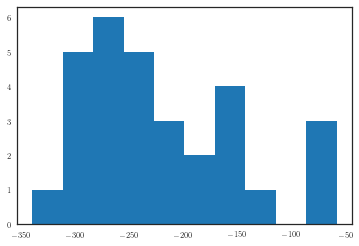

In [ ]:
plt.hist(_aicc)